# Shadow-Price-Guided Economic Attacks with Concept-Level Interpretability

This notebook consolidates the complete experiment for an IEEE Power
Engineering Letters study.  The **shadow-price-guided attack (SPGA)** is the
primary method; the concept bottleneck model (CBM) is used only to decompose
economic vulnerability into energy, congestion, and ramping mechanisms.

The notebook intentionally retains two publication figures, each in a compact
1$\times$2 IEEE single-column format.

## 1. Core formulation

The forecaster produces $\widehat{\boldsymbol w}=f_\theta(\boldsymbol x)$ and
the adversarial input satisfies

$$
\boldsymbol x^{\rm adv}=\boldsymbol x+\boldsymbol\delta,
\qquad \|\boldsymbol\delta\|_\infty\leq\epsilon.
$$

Conventional FGSM and PGD attacks maximize prediction error.  In contrast,
SPGA uses the shadow-price sensitivity of the downstream dispatch:

$$
\boldsymbol s=\nabla_{\widehat{\boldsymbol w}}\mathcal C
\approx \boldsymbol B^\top\boldsymbol\lambda^\star,
$$

and maximizes the first-order economic surrogate

$$
\max_{\|\boldsymbol\delta\|_\infty\leq\epsilon}
\boldsymbol s^\top
\left[f_\theta(\boldsymbol x+\boldsymbol\delta)
-f_\theta(\boldsymbol x)\right].
$$

The dispatch is solved once to obtain the shadow prices; the attack iterations
do not repeatedly solve OPF.

## 2. Experimental protocol

- Real 15-min wind-power measurements and the IEEE 33-bus system.
- Previous 12 h predict the following 4 h.
- Chronological 70%/15%/15% train/validation/test split.
- FGSM and PGD are prediction-oriented baselines.
- All attacks use the same $L_\infty$ perturbation budget.
- Operating-cost effects are verified using the unchanged dispatch with
  generator, network-flow, and intertemporal ramping constraints.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

FIG_DIR = Path("pes_letter_figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Nimbus Roman", "Times New Roman", "Times"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Nimbus Roman",
    "mathtext.it": "Nimbus Roman:italic",
    "mathtext.bf": "Nimbus Roman:bold",
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.25,
    "lines.markersize": 4.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

IEEE plotting style initialized (8 pt, single-column width).


## 3. Shadow-price attack results

Figure 1 is the main PES Letter result.  PGD produces the largest forecasting
error, whereas SPGA consistently causes the largest operating-cost increase.
This directly demonstrates that prediction vulnerability is not equivalent to
operational vulnerability.

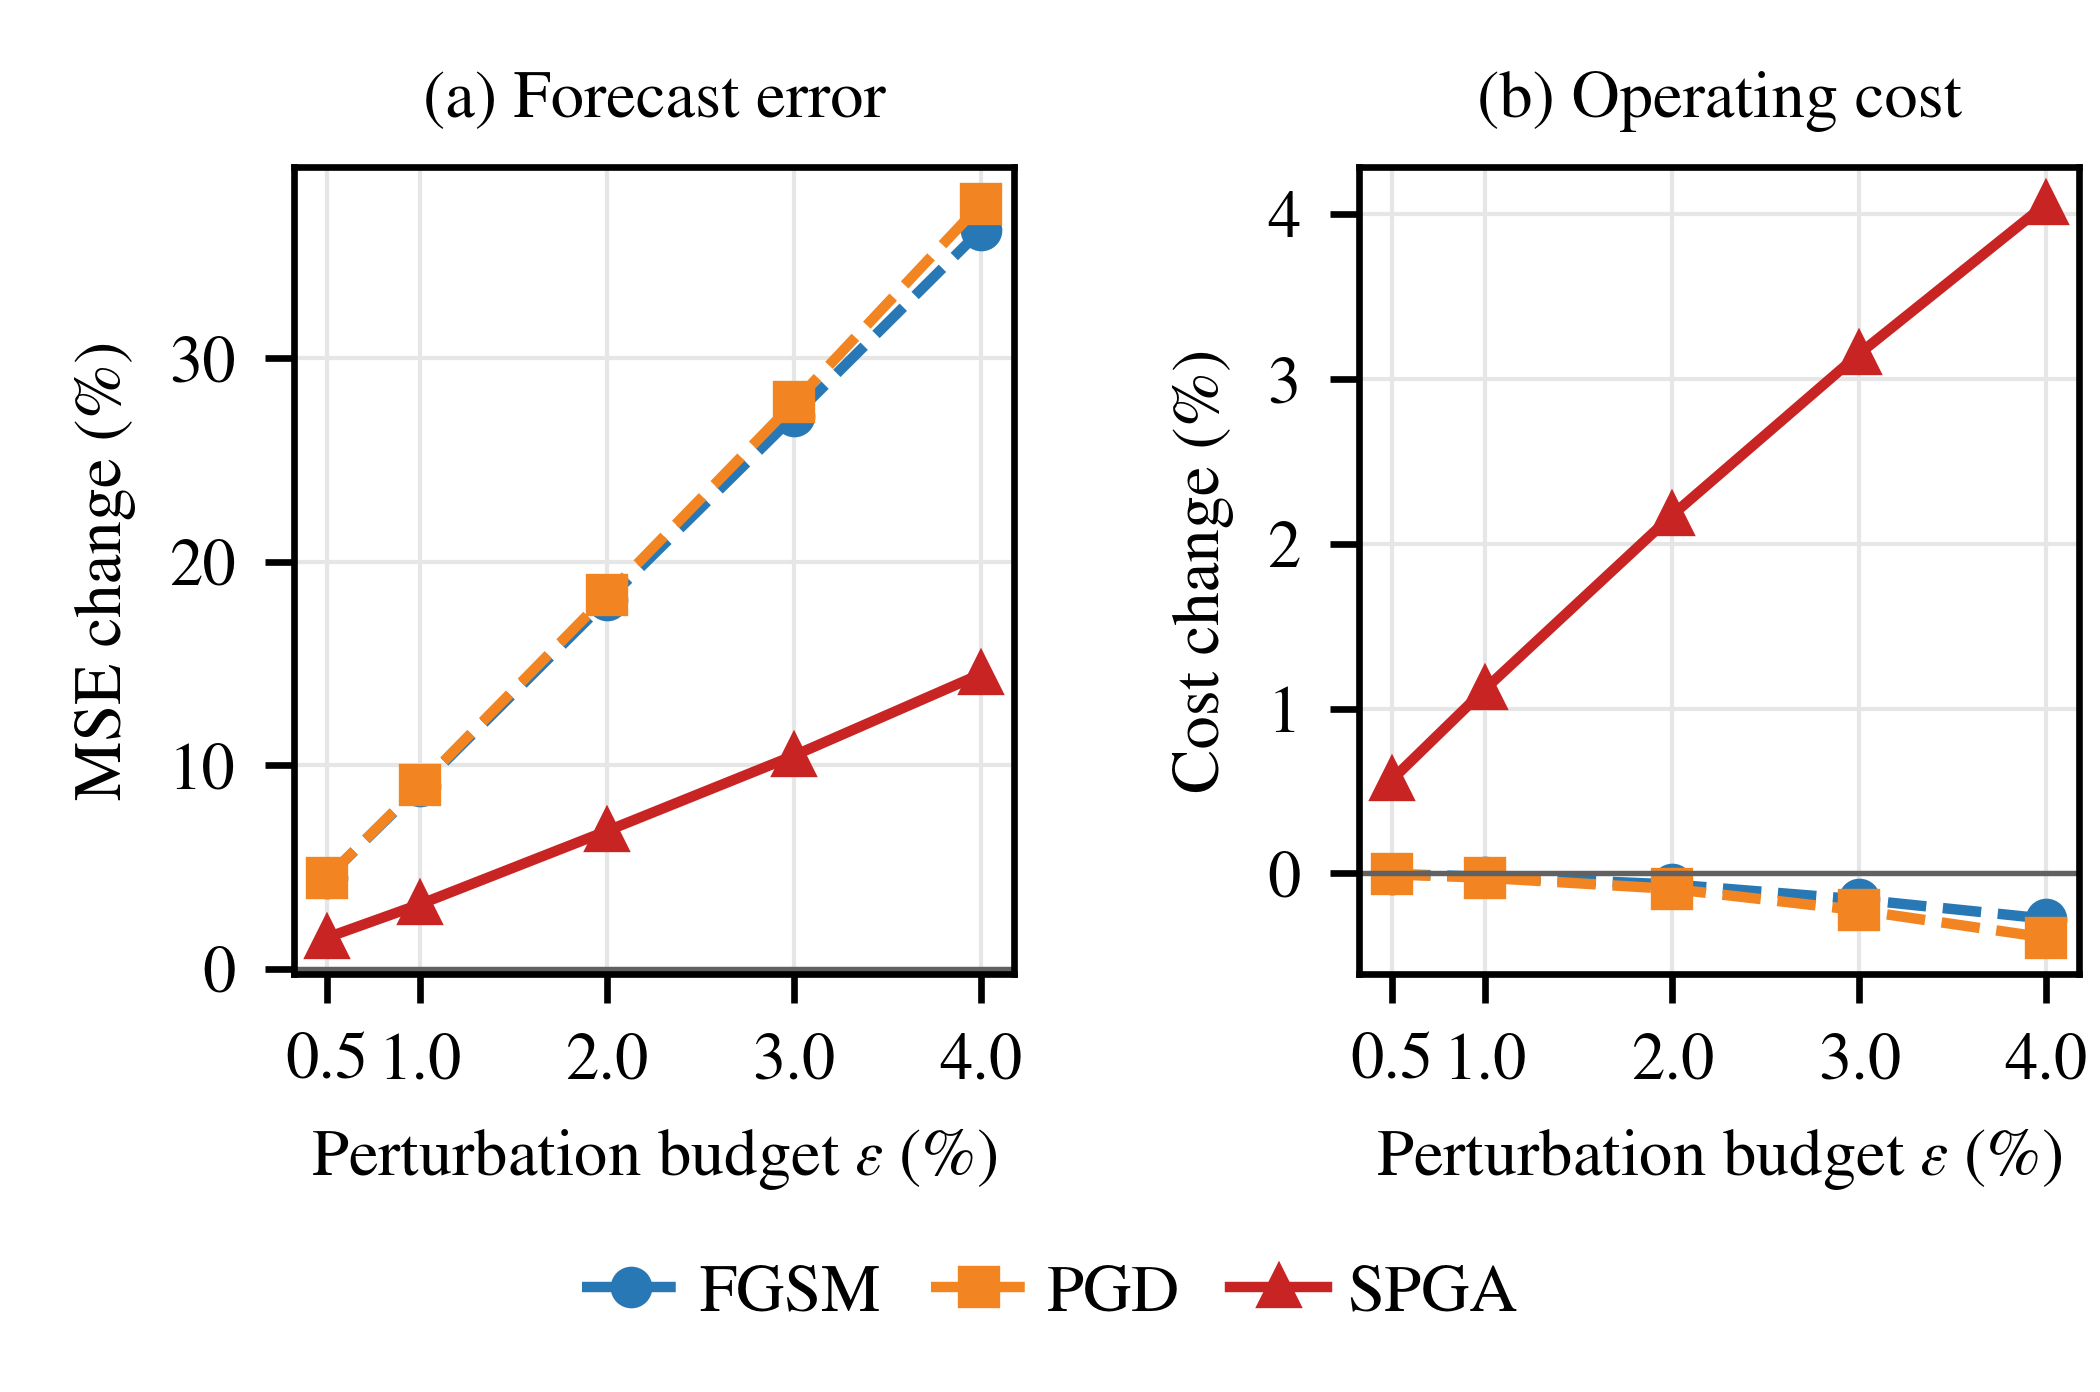

In [2]:
results = pd.read_csv("experiment_results.csv")
budget = results[results["Attack"] != "No attack"].copy()
styles = {
    "FGSM": ("#2878B5", "o", "--"),
    "PGD": ("#F28522", "s", "--"),
    "SPGA": ("#C82423", "^", "-"),
}

fig, axes = plt.subplots(1, 2, figsize=(3.5, 2.32))
for method in ["FGSM", "PGD", "SPGA"]:
    subset = budget[budget["Attack"] == method].sort_values("epsilon")
    color, marker, linestyle = styles[method]
    x = 100 * subset["epsilon"]
    axes[0].plot(x, subset["dMSE_%"], color=color, marker=marker,
                 ls=linestyle, label=method)
    axes[1].plot(x, subset["dCost_%"], color=color, marker=marker,
                 ls=linestyle, label=method)

axes[0].set_title("(a) Forecast error")
axes[0].set_xlabel(r"Perturbation budget $\epsilon$ (%)")
axes[0].set_ylabel("MSE change (%)")
axes[1].set_title("(b) Operating cost")
axes[1].set_xlabel(r"Perturbation budget $\epsilon$ (%)")
axes[1].set_ylabel("Cost change (%)")
for ax in axes:
    ax.axhline(0, color=".38", lw=.65)
    ax.set_xticks([0.5, 1, 2, 3, 4])
    ax.grid(color=".90", lw=.5)
    ax.set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(.5, .005),
           ncol=3, frameon=False, handlelength=1.45,
           columnspacing=.75, handletextpad=.30)
fig.subplots_adjust(left=.14, right=.99, top=.88, bottom=.30, wspace=.48)
fig.savefig(FIG_DIR / "fig1_spga_budget.pdf")
fig.savefig(FIG_DIR / "fig1_spga_budget.png", dpi=600)
plt.show()

**Fig. 1. Prediction and economic effects across perturbation budgets.**

In [3]:
main = pd.read_csv("experiment_results.csv")
main = main[main["epsilon"].eq(0.02)][["Attack", "MSE", "dMSE_%", "Cost_$", "dCost_%"]]
main

Method,MSE,MSE change (%),Cost ($),Cost change (%)
No attack,0.065,0.000,440.171,0.000
FGSM,0.077,18.107,439.871,-0.068
PGD,0.077,18.367,439.751,-0.096
SPGA,0.069,6.780,449.746,2.175


At the 2% budget, PGD increases MSE by 18.367% but decreases
operating cost by 0.096%.  SPGA increases MSE by only 6.780% while increasing
operating cost by 2.175%.  Therefore, the most damaging prediction attack is
not necessarily the most damaging economic attack.

## 4. CBM extension: concept-level interpretation

The CBM decomposes the economic response into

$$
(\widehat C^{\rm ene},\widehat C^{\rm con},\widehat C^{\rm ramp}),
\qquad
\widehat{\mathcal C}=\sum_k\widehat C^k.
$$

The corresponding concept sensitivities satisfy

$$
\boldsymbol s^k=\nabla_{\widehat{\boldsymbol w}}\widehat C^k,
\qquad
\sum_k\boldsymbol s^k\approx\boldsymbol s.
$$

SPGA-E, SPGA-C, and SPGA-R use these sensitivities to target energy,
congestion, and ramping mechanisms, respectively.  They are extensions of
SPGA rather than independent attack frameworks.

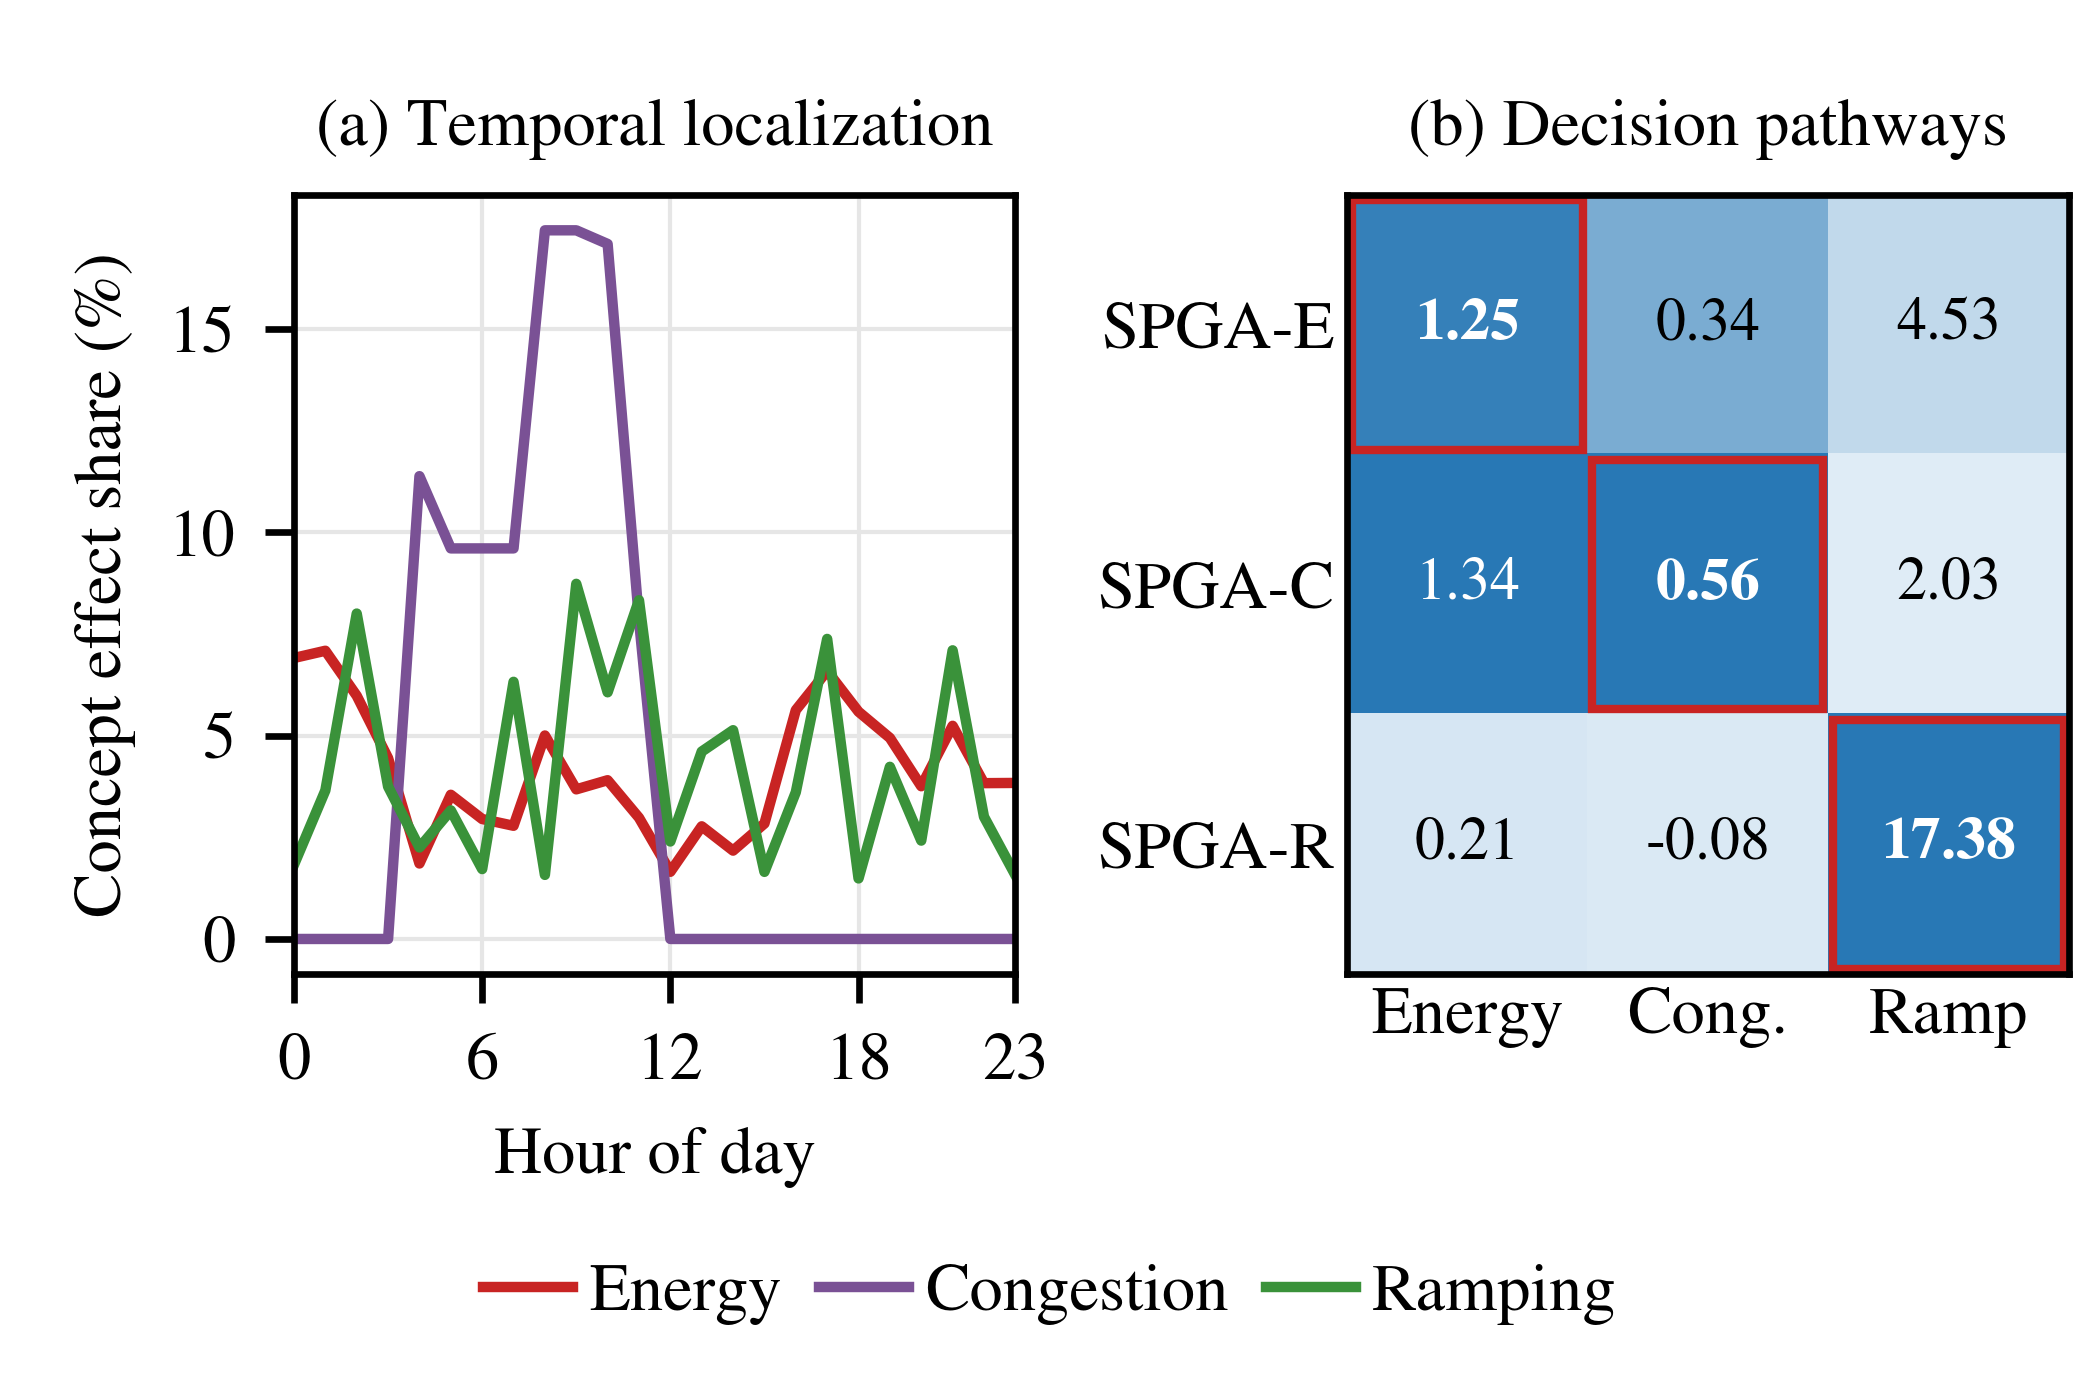

In [4]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

day = pd.read_csv("one_day_concept_example.csv")
hour_bin = day["Hour"].astype(int)
effects = {
    "Energy": (day["Energy_CA_total_generation_MW"]
               - day["Clean_total_generation_MW"]).abs(),
    "Congestion": (day["Congestion_CA_critical_flow_MW"]
                   - day["Clean_critical_flow_MW"]).abs(),
    "Ramping": (day["Ramping_CA_aggregate_ramp_MW"]
                - day["Clean_aggregate_ramp_MW"]).abs(),
}
temporal = pd.DataFrame(index=range(24))
for concept, values in effects.items():
    hourly = values.groupby(hour_bin).sum().reindex(range(24), fill_value=0.0)
    temporal[concept] = 100.0 * hourly / hourly.sum()

cross = pd.read_csv("one_day_concept_decision_vs_forecast.csv")
matrix = cross[["Energy_delta_pct", "Congestion_delta_pct",
                "Ramping_delta_pct"]].to_numpy(float)
# Shade is normalized within each decision column; labels retain actual changes.
shade = np.abs(matrix) / np.maximum(np.abs(matrix).max(axis=0), 1e-12)
cmap = LinearSegmentedColormap.from_list("impact", ["#F7FBFF", "#2878B5"])
colors = {"Energy": "#C82423", "Congestion": "#7A5195", "Ramping": "#3A923A"}

fig, axes = plt.subplots(1, 2, figsize=(3.5, 2.32))
for concept in ["Energy", "Congestion", "Ramping"]:
    axes[0].plot(range(24), temporal[concept], color=colors[concept],
                 label=concept)
axes[0].set_title("(a) Temporal localization")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Concept effect share (%)")
axes[0].set_xlim(0, 23)
axes[0].set_xticks([0, 6, 12, 18, 23])
axes[0].grid(color=".90", lw=.5)
axes[0].set_axisbelow(True)

axes[1].imshow(shade, cmap=cmap, vmin=0, vmax=1, aspect="auto")
axes[1].set_title("(b) Decision pathways")
axes[1].set_xticks(range(3), ["Energy", "Cong.", "Ramp"])
axes[1].set_yticks(range(3), ["SPGA-E", "SPGA-C", "SPGA-R"])
axes[1].tick_params(length=0, pad=1.5)
for i in range(3):
    for j in range(3):
        color = "white" if shade[i, j] > 0.60 else "black"
        axes[1].text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                     color=color, fontsize=7.2,
                     fontweight="bold" if i == j else "normal")
        if i == j:
            axes[1].add_patch(plt.Rectangle((j-.48, i-.48), .96, .96,
                              fill=False, edgecolor="#C82423", lw=1.0))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(.5, .005),
           ncol=3, frameon=False, handlelength=1.35,
           columnspacing=.55, handletextpad=.25)
fig.subplots_adjust(left=.14, right=.985, top=.86, bottom=.30, wspace=.46)
fig.savefig(FIG_DIR / "fig2_cbm_decisions.pdf")
fig.savefig(FIG_DIR / "fig2_cbm_decisions.png", dpi=600)
plt.show()

**Fig. 2. Temporal localization and decision effects of concept attacks.**

In [5]:
cross = pd.read_csv("one_day_concept_decision_vs_forecast.csv")
cross["Attack"] = cross["Attack"].replace({"Energy-CA":"SPGA-E", "Congestion-CA":"SPGA-C", "Ramping-CA":"SPGA-R"})
cross = cross[["Attack", "Energy_delta_pct", "Congestion_delta_pct", "Ramping_delta_pct"]]
cross

Attack,Energy decision (%),Congestion decision (%),Ramping decision (%)
SPGA-E,1.250,0.337,4.528
SPGA-C,1.343,0.562,2.031
SPGA-R,0.213,-0.079,17.380


The left panel localizes each mechanism over the representative
day.  Energy effects are broadly distributed, congestion effects concentrate
around the network-constrained morning interval, and ramping effects are more
intermittent.  The right panel reports the actual percentage changes relative
to the clean forecast; color intensity is normalized within each decision
column.  SPGA-C increases critical-line-flow decisions by 0.562%, while SPGA-R
increases aggregate ramping by 17.380%.  Off-diagonal effects expose physical
coupling rather than implying artificial concept independence.

## 5. PES Letter takeaway

The paper should retain only two contributions:

1. SPGA converts downstream shadow prices into an efficient economic attack
   direction without repeated OPF solves during attack iterations.
2. The CBM extension decomposes this economic vulnerability into interpretable
   energy, congestion, and ramping pathways and enables concept-targeted SPGA.

The main performance comparison and the representative-day concept analysis
use separate reporting scopes; their cost baselines are therefore not mixed in
one table.